### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

from scipy.stats import spearmanr

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
#Check the data content
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

## Observations

1. There are 26 data fields.
2. Cleaned the column names.

**Missing values by column**

3. Checked the number and percentage of missing values for each column and found the following:
   - There are 6 variables with missing values.
   - The 'car' variable has more than 99% missing values, so we will drop it.
   - The other 5 variables each have less than 2% missing values. We will investigate them further before deciding whether to remove those records. Excluding them should have little to no impact on the analysis.

**Duplicated Rows**

4. Checked the number of duplicated rows and the content for a specific pattern. 
   - There are 74 cases of more acccepted cases.
   - Checked the data for the duplicates and it looks like many cases are of accept and 66% of coupons are for Carry out & Take away. 
   - The duplicates may be the same answers by different drivers but we cannot confirm because there is no unique identifier for each respondent. Moreover, given that this is a result of a survey, it is possible to have the same responses.

We will keep the duplicates for now and see if they have any effect on the analysis.

**Check and update the data types**

5. The majority of the data fields are of type object and it is best to make updates but first we looked at the missing values by column.

6. Check first a group of columns that have numberical values. We will check the counts of each unique value in these columns
list_num = ['has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']

We notice that the data field toCoupon_GEQ5min Counts has only values of 1, meaning that all cars are at least 5 minutes away from the venue of the coupon. 
Given that all of them are one, there is no additional value and I will drop the column.
Also, direction_same and direction_opp contain the same information and we can drop one column. 

In [4]:
#list the columns in the dataset
#print(data.columns)

data.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'car',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50',
 'toCoupon_GEQ5min',
 'toCoupon_GEQ15min',
 'toCoupon_GEQ25min',
 'direction_same',
 'direction_opp',
 'Y']

In [5]:
data.columns = data.columns.str.strip()  # Remove leading/trailing whitespace from column names

In [6]:
#Check the data types of each column
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

Observation - The majority of the data fields are of type object and it is best to make updates but first we look at the missing values by column.


In [7]:
#Check the number of missing values in each column and print only columns with missing values
missing_by_col = data.isnull().sum()
print(missing_by_col[missing_by_col > 0])

car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64


There is a very large number of missing values for the car data field. We will also check the percentage missing for each column, to understand better the magnitude.

In [8]:
#Checking only the columns with missing values

missing_pct_y_col = data.isnull().sum() / data.shape[0] * 100

print(missing_pct_y_col[missing_pct_y_col > 0])

car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
dtype: float64


#Check for duplicated values/rows

In [9]:
#Check for duplicate rows in the dataset

data.duplicated().any() #True if there are any duplicate rows

data.duplicated().sum() # Number of duplicate rows

74

In [10]:
#The data has 74 duplicate rows. We will display them to see if they are exact duplicates or if there are any differences in the other columns.
print(f"Duplicate rows: {data.duplicated().sum()}")

if data.duplicated().sum() > 0:
    display(data[data.duplicated(keep=False)].sort_values(list(data.columns)))

Duplicate rows: 74


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
6968,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7853,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7407,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
8509,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
7406,Home,Alone,Sunny,30,6PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,below21,Single,...,less1,gt8,1~3,never,1,1,1,0,1,1
6974,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7859,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7414,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1


In [11]:
#Checked the data for the duplicates and it looks like many cases are of accept and 66% of coupons are for Carry out & Take away. 
# The duplicates may be the same answers by different drivers but we cannot confirm becuase there is no unique identifier for each driver. 
# We will keep the duplicates for now and see if they have any effect on the analysis.

data_dups = data[data.duplicated()]

print(f"Duplicate rows by coupon: {data_dups['coupon'].value_counts().to_string()}")

print(f"Duplicate rows: {data_dups.shape[0]}")
print(f"Y values in duplicates: {data_dups['Y'].value_counts().to_string()}")

Duplicate rows by coupon: coupon
Carry out & Take away    49
Coffee House              7
Bar                       7
Restaurant(<20)           7
Restaurant(20-50)         4
Duplicate rows: 74
Y values in duplicates: Y
1    53
0    21


#Check the data types and make updates, as needed

In [12]:
#These are the columns that have numberical values. We will check the counts of each unique value in these columns.
list_num = ['has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']

for col in list_num:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()  # Blank line for readability

has_children Counts
has_children
0    7431
1    5253
Name: count, dtype: int64

toCoupon_GEQ5min Counts
toCoupon_GEQ5min
1    12684
Name: count, dtype: int64

toCoupon_GEQ15min Counts
toCoupon_GEQ15min
1    7122
0    5562
Name: count, dtype: int64

toCoupon_GEQ25min Counts
toCoupon_GEQ25min
0    11173
1     1511
Name: count, dtype: int64

direction_same Counts
direction_same
0    9960
1    2724
Name: count, dtype: int64

direction_opp Counts
direction_opp
1    9960
0    2724
Name: count, dtype: int64

Y Counts
Y
1    7210
0    5474
Name: count, dtype: int64



We notice that the data field toCoupon_GEQ5min Counts has only values of 1, meaning that all cars are at least 5 minutes away from the venue of the coupon. 
Given that all of them are one, there is no additional value and I will drop the column.
Also, direction_same and direction_opp contain the same information and we can drop one column. 

In [13]:
#These are the columns with missing values. We will convert them to categorical data type.
columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in columns:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()

Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64



3. Decide what to do about your missing data -- drop, replace, other...



1. Make a copy of the original dataset, to be able to clean up and not affect the original. 
2. Drop the columns 'Car' (over 99% missing values), 'toCoupon_GEQ5min' (all 1), and 'direction_opp' (same information as 'direction_same') from the dataset.

3. Check the counts/distribution for each variable and determine if to make it categorical or numeric. 
    - Treat "income" separately because we want to keep the ascending order 
    - Check the frequecies of the columns with missing values. We will convert them to categorical data type.
    
    columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

    - For the variables with missing values, we will add a category "unk", to have the option of including or excluding from analysis

4. Create a dataset (df_unk) that removes all the rows that have "unk" in the Bar, CoffeeHouse, or CarryAway columns. We can use it if we need to analyze the data without the missing values. We will keep the original dataframe df for further analysis.

#Look for outliers

In [14]:
#First, drop the columns 'Car' (over 99% missing values), 'toCoupon_GEQ5min' (all 1), and 'direction_opp' (same information as 'direction_same') from the dataset.

df = data.copy()

df = df.drop(columns=['car', 'toCoupon_GEQ5min', 'direction_opp'])

print(df.columns.tolist())

['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'Y']


In [15]:
#The list_num was defined earlier in the code. It contains the names of the columns that we want to convert to numeric data type, except the dropped columns. 
# We will now convert these columns to numeric data type.

list_num = ['has_children', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'Y']

df[list_num] = df[list_num].apply(pd.to_numeric, errors="coerce")

#For income, we add the order for the buckets to be able to follow in tables and graphs

In [16]:
income_order = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999",
    "$50000 - $62499",
    "$62500 - $74999",
    "$75000 - $87499",
    "$87500 - $99999",
    "$100000 or More"
]

df["income"] = pd.Categorical(
    df["income"],
    categories=income_order,
    ordered=True
)

In [17]:
df["income"].value_counts(dropna=False)

#This is to check if the ordering of the income categories is correct. We will sort the dataframe by income and display the first 20 rows.
df.sort_values("income")[["income"]].head(20)

,income
5917,Less than $12500
11531,Less than $12500
11532,Less than $12500
11533,Less than $12500
11534,Less than $12500
11535,Less than $12500
11536,Less than $12500
11537,Less than $12500
11538,Less than $12500
11539,Less than $12500


In [18]:
#Check the values to see if these data fields are categorical or numerical. We will print the counts of each unique value in these columns.
list_catn = ['temperature', 'time', 'age', 'education', 'occupation']

for col in list_catn:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print() 

for col in list_catn:
    df[col] = df[col].astype('category')

temperature Counts
temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64

time Counts
time
6PM     3230
7AM     3164
10AM    2275
2PM     2009
10PM    2006
Name: count, dtype: int64

age Counts
age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

education Counts
education
Some college - no degree                  4351
Bachelors degree                          4335
Graduate degree (Masters or Doctorate)    1852
Associates degree                         1153
High School Graduate                       905
Some High School                            88
Name: count, dtype: int64

occupation Counts
occupation
Unemployed                                   1870
Student                                      1584
Computer & Mathematical                      1408
Sales & Related                              1093
Education&Training&Library                    943
Management     

In [19]:
#The list below is a list of categorical columns in the dataset. We will print the counts of each unique value in these columns and then convert to categorical data type.

list_cat = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'destination', 'coupon', 'expiration', 'gender', 'maritalStatus', 'passanger', 'weather']

for col in list_cat:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()

Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64

destination Counts
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64

coupon Counts
coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(

In [20]:
list_cat = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'destination', 'coupon', 'expiration', 'gender', 'maritalStatus', 'passanger', 'weather']

for col in list_cat:
    df[col] = df[col].astype('category')

#df.info()

#For the variables with missing values, we will add a category "unk", to have the option of including or excluding from analysis

In [21]:
list_unk = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in list_unk:
    df[col] = df[col].cat.add_categories('unk').fillna('unk')

In [22]:
#Check the results of the missing value imputation
columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in columns:
    print(f"{col} Counts")
    print(df[col].value_counts(dropna=False))
    print()

Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
unk       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
unk       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
unk       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
unk       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
unk       189
Name: count, dtype: int64



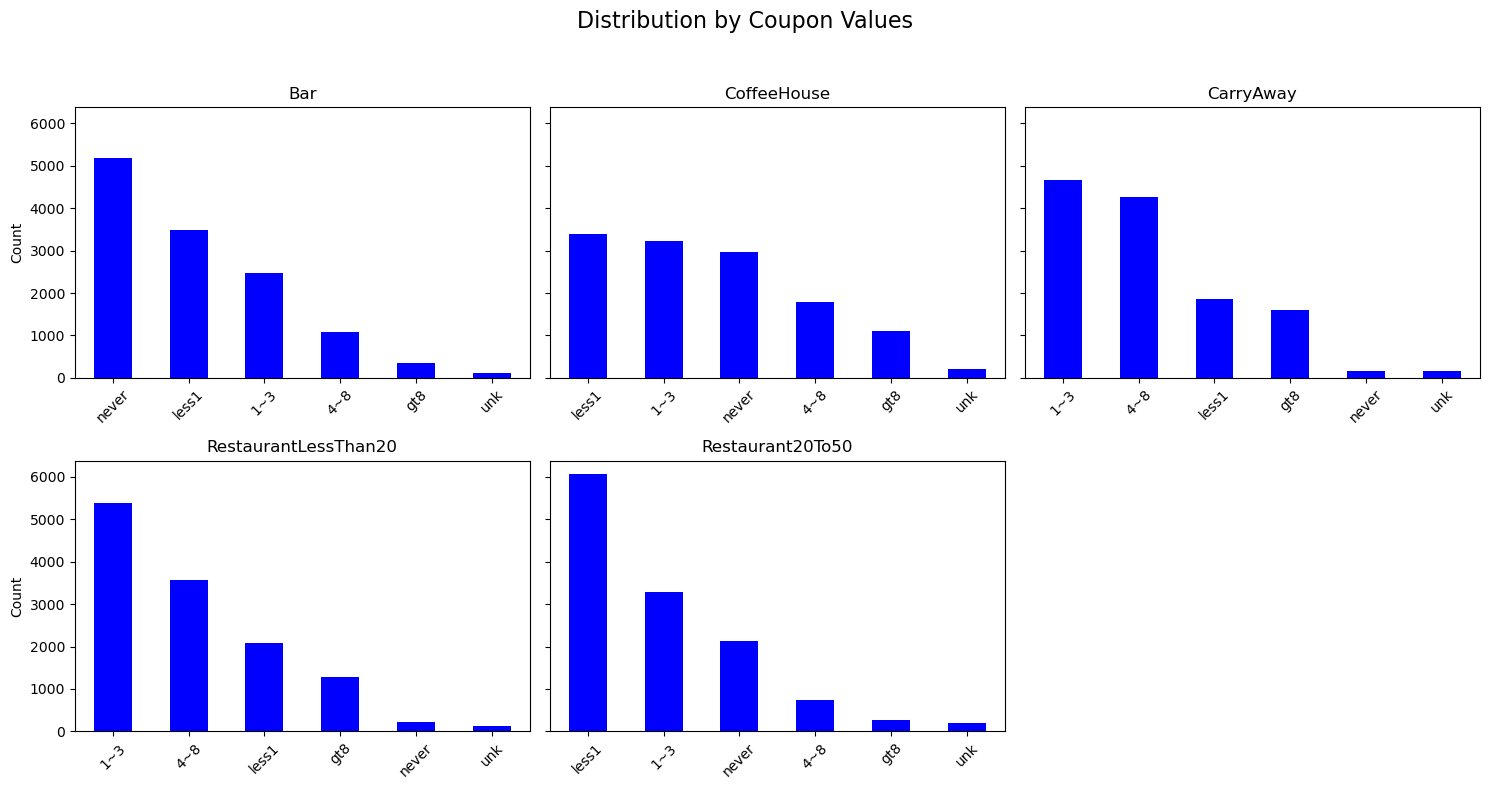

In [24]:
columns = ['Bar', 'CoffeeHouse', 'CarryAway',
           'RestaurantLessThan20', 'Restaurant20To50']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for i, col in enumerate(columns):
    counts = df[col].value_counts(dropna=False)

    counts.plot(
        kind='bar',
        ax=axes[i],
        color='blue'
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Remove the unused subplot
fig.delaxes(axes[-1])

fig.suptitle("Distribution by Coupon Values", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [25]:
#Have a table format to check the overlap of the coupons in the dataset. We will create a crosstab of the coupon columns to see how many observations have each combination of coupons.

pd.crosstab(
    df["Bar"],
    df["CoffeeHouse"],
    normalize="index"
).mul(100).round(1)

CoffeeHouse,1~3,4~8,gt8,less1,never,unk
Bar,,,,,,
1~3,23.0,26.0,10.5,21.9,17.8,0.8
4~8,36.5,18.4,14.3,14.4,14.3,2.0
gt8,18.9,18.9,37.5,12.6,12.0,0.0
less1,29.8,11.2,6.3,35.2,16.4,1.3
never,21.9,9.4,6.7,26.5,33.8,1.7
unk,20.6,0.0,0.0,40.2,0.0,39.3


In [26]:
#Create a dataset that removes all the rows that have "unk" in the Bar, CoffeeHouse, or CarryAway columns. We can use it if we need to analyze the data without the missing values. 
# We will keep the original dataframe df for further analysis.

df_unk = df.copy()

rows_before = len(df_unk)

cols = ["Bar", "CoffeeHouse", "CarryAway"]
df_unk = df_unk[df_unk[cols].ne("unk").all(axis=1)]

rows_after = len(df_unk)

print(f"Removed {rows_before - rows_after} rows.")
print(f"Remaining rows: {rows_after}")

Removed 391 rows.
Remaining rows: 12293


In [27]:
#There are 42 observations with "unk" in the Bar, CoffeeHouse, or CarryAway columns, at the same time. 
# We will remove these rows from the dataset and keep the columns that have only one instance of missing, for instance, only Bar is missing but CoffeeHouse and CarryAway are not missing. 

rows_before = len(df)

condition = (
    (df["Bar"] == "unk") &
    (df["CoffeeHouse"] == "unk") &
    (df["CarryAway"] == "unk")
)

df_3unk = df[~condition]

rows_after = len(df_3unk)

print(f"Removed {rows_before - rows_after} rows.")
print(f"Before: {rows_before} rows.")
print(f"Remaining rows: {rows_after}")


Removed 42 rows.
Before: 12684 rows.
Remaining rows: 12642


4. What proportion of the total observations chose to accept the coupon?

#Approximately 57% (7,210 out of 12,684) of the total drivers accepted the coupon.

In [28]:
acceptance_rate = (df['Y'] == 1).mean() * 100

print(f"Coupon Acceptance Rate: {acceptance_rate:.2f}%")
print(acceptance_rate)


Coupon Acceptance Rate: 56.84%
56.84326710816777


Coupon Acceptance Rate: 56.84%
Y
1    56.843267
0    43.156733
Name: count, dtype: float64


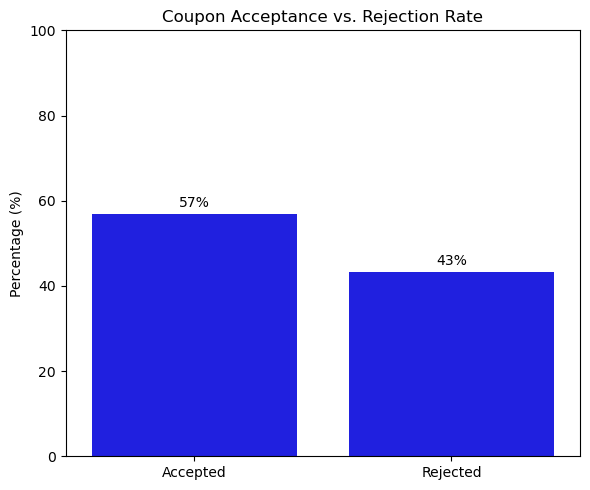

In [29]:
#Alternative way with graph

# Calculate percentages
coupon_accept = df['Y'].value_counts() / df.shape[0] * 100

print(f"Coupon Acceptance Rate: {coupon_accept[1]:.2f}%")
print(coupon_accept)

# Convert to DataFrame
coupon_plot = coupon_accept.reset_index()
coupon_plot.columns = ['Y', 'Percentage']

# Change 0 and 1 to readable labels
coupon_plot['Response'] = coupon_plot['Y'].map({
    0: 'Rejected',
    1: 'Accepted'
})

# Create bar chart
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=coupon_plot,
    x='Response',
    y='Percentage',
    color='blue'
)

# Add percentage labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3)

plt.title('Coupon Acceptance vs. Rejection Rate')
plt.xlabel('')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [30]:
coupon_accept = df['Y'].value_counts()
print(coupon_accept)

Y
1    7210
0    5474
Name: count, dtype: int64


5. Use a bar plot to visualize the `coupon` column.

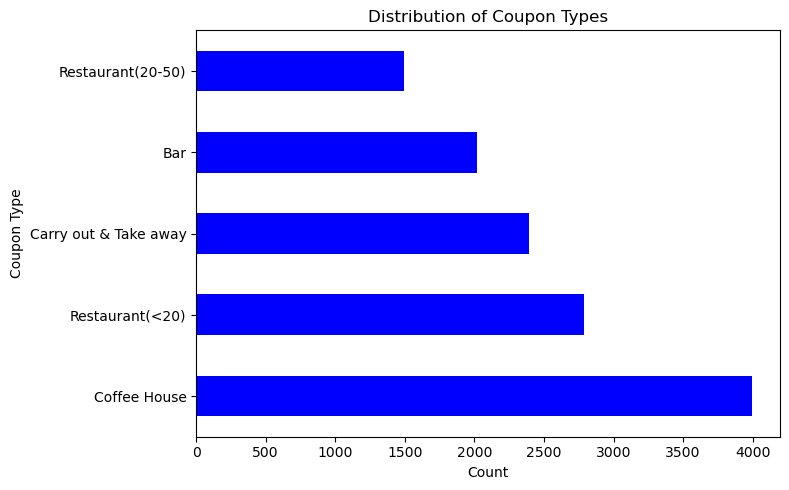

In [31]:
coupon_counts = df['coupon'].value_counts()

plt.figure(figsize=(8,5))
coupon_counts.plot(kind='barh', color='blue')

plt.title('Distribution of Coupon Types')
plt.xlabel('Count')
plt.ylabel('Coupon Type')
plt.tight_layout()
plt.show()

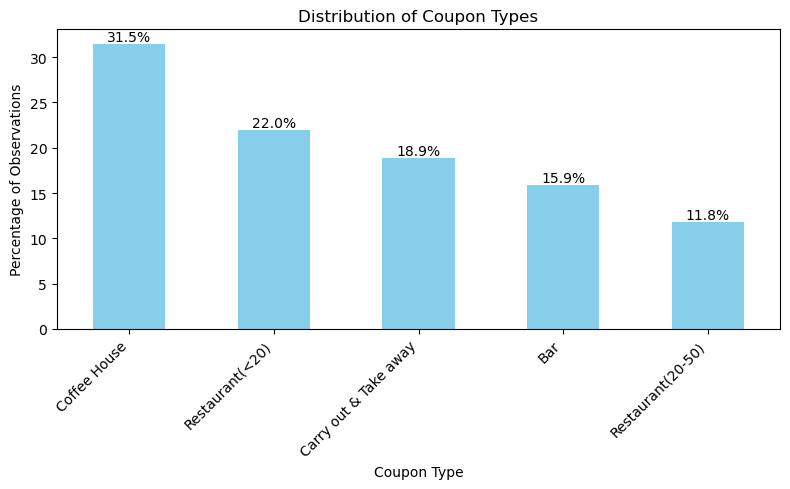

In [32]:
coupon_pct = df['coupon'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))

ax = coupon_pct.plot(
    kind='bar',
    color='skyblue'
)

# Add percentage values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Percentage of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
print(df['coupon'].value_counts())

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64


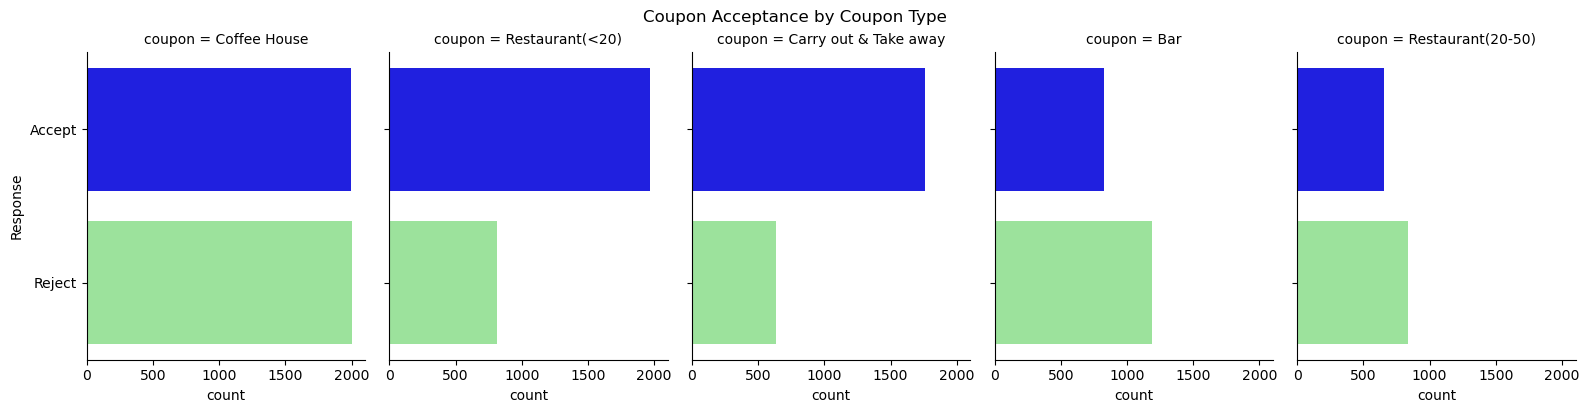

In [34]:
df["Response"] = df["Y"].map({
    0: "Reject",
    1: "Accept"
})

g = sns.catplot(
    y="Response",
    col="coupon",
    hue="Response",
    data=df[df["coupon"].notnull()],
    kind="count",
    height=4,
    aspect=0.8,
    palette=["blue", "lightgreen"],
    col_order=['Coffee House', 'Restaurant(<20)', 'Carry out & Take away', 'Bar', 'Restaurant(20-50)']
)

g.fig.suptitle(
    "Coupon Acceptance by Coupon Type",
    y=1.02
)

plt.show()



By accepted count:


Y,0,1
coupon,,
Coffee House,2001,1995
Restaurant(<20),816,1970
Carry out & Take away,633,1760
Bar,1190,827
Restaurant(20-50),834,658



By total coupon count:


Y,0,1
coupon,,
Coffee House,2001,1995
Restaurant(<20),816,1970
Carry out & Take away,633,1760
Bar,1190,827
Restaurant(20-50),834,658


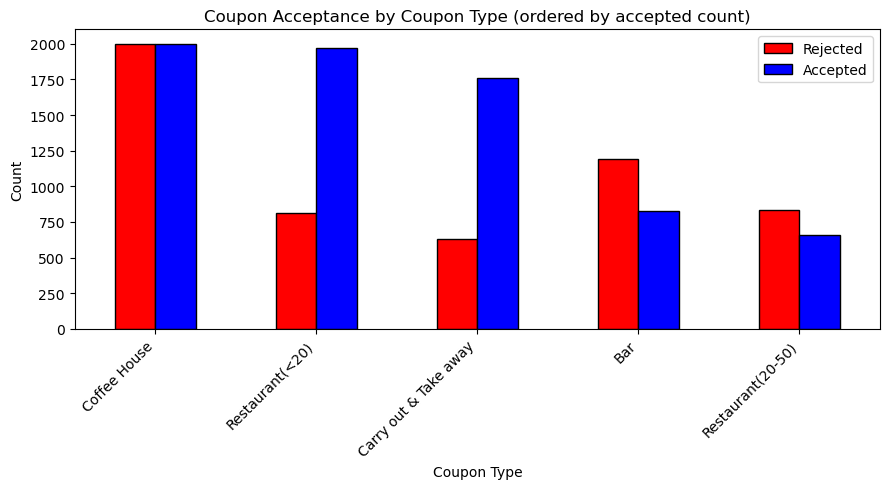

In [35]:
coupon_ct = pd.crosstab(df['coupon'], df['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['red', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Coupon Type (ordered by accepted count)')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

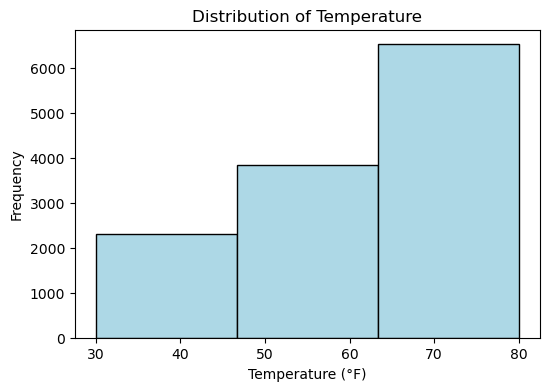

In [36]:
plt.figure(figsize=(6,4))

plt.hist(df['temperature'], bins= 3, color = 'lightblue', edgecolor='black')

plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')

plt.show()

A bar plot was added below because the data field temperature has only three unique values (30°F, 55°F, and 80°F). Therefore, the histogram appears similar to a bar chart because the variable is discrete rather than continuous.

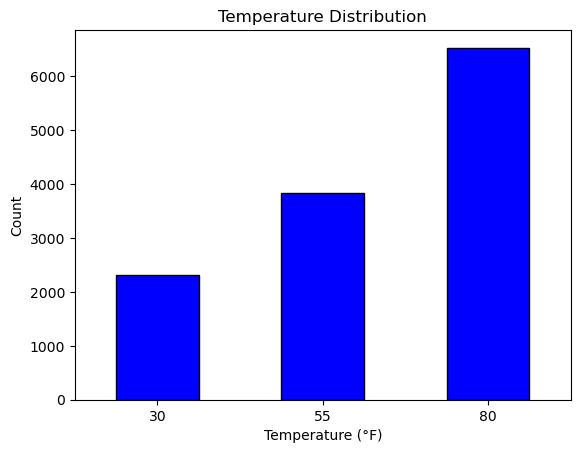

In [37]:
temp_counts = df['temperature'].value_counts().sort_index()

temp_counts.plot(kind='bar', color = 'blue', edgecolor='black')

plt.title('Temperature Distribution')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

By accepted count:


Y,0,1
temperature,,
80,2609,3919
55,1779,2061
30,1086,1230



By total coupon count:


Y,0,1
temperature,,
80,2609,3919
55,1779,2061
30,1086,1230


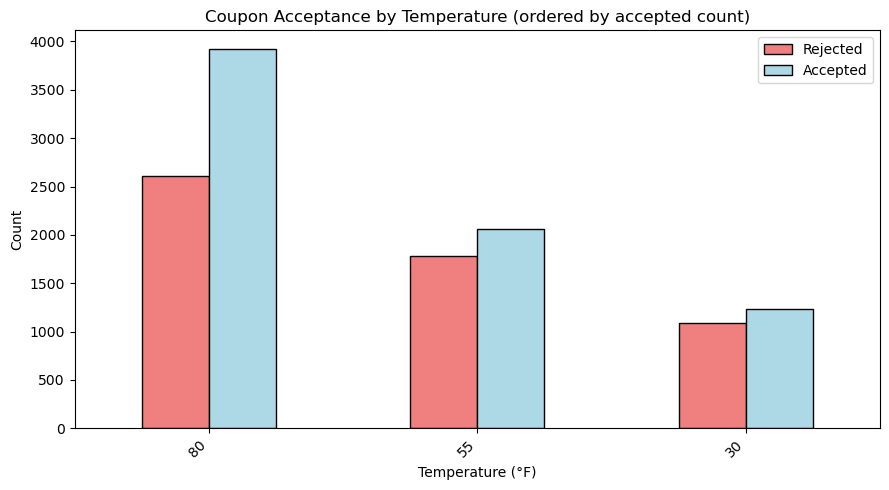

In [38]:
coupon_ct = pd.crosstab(df['temperature'], df['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'lightblue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Temperature (ordered by accepted count)')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [84]:
#df_bar = df_unk.query('coupon == "Bar"')

df_bar = df[df["coupon"] == "Bar"].copy()

#df_bar.info()

In [40]:
df_bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y,Response
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,unk,4~8,1~3,1,0,0,0,Reject
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,unk,4~8,1~3,0,0,1,1,Accept
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,unk,4~8,1~3,1,1,0,0,Reject
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,Accept
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,1,1,Accept


In [86]:
df_bar.value_counts(['Bar'])

#df_bar.value_counts(['coupon'])


Bar  
never    830
less1    570
1~3      397
4~8      150
gt8       49
unk       21
Name: count, dtype: int64

2. What proportion of bar coupons were accepted?


In [87]:
bar_acceptance_rate = df_bar['Y'].mean()

print(f"Bar coupon acceptance rate: {bar_acceptance_rate:.1%}")

Bar coupon acceptance rate: 41.0%


In [88]:
pd.crosstab(df_bar['coupon'], df_bar['Y'])

Y,0,1
coupon,,
Bar,1190,827


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [89]:
print(df_bar['Bar'].value_counts())

conditions = [
    df_bar['Bar'].isin(['never', 'less1', '1~3']),
    df_bar['Bar'].isin(['4~8', 'gt8'])
]

choices = ['3 or fewer', 'More than 3']

df_bar['Bar_group'] = np.select(
    conditions,
    choices,
    default='unk'
)

print("Value counts of Bar_group column in df_bar DataFrame:")
print(df_bar['Bar_group'].value_counts())


Bar
never    830
less1    570
1~3      397
4~8      150
gt8       49
unk       21
Name: count, dtype: int64
Value counts of Bar_group column in df_bar DataFrame:
Bar_group
3 or fewer     1797
More than 3     199
unk              21
Name: count, dtype: int64


Drivers who visited a bar three or fewer times per month had an acceptance rate of 56.2%, compared with 62.2% among drivers who visited a bar more than three times per month. Therefore, the drivers who visit the bar mopre frequently are more likely to accept the bar coupon by 6 percentage points.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?

In [45]:
bar = ["1~3", "4~8", "gt8"]
age = ["26", "31", "36", "41", "46", "50plus"]

condition = (df_bar["Bar"].isin(bar) & df_bar["age"].isin(age))

accepted_group = df_bar.loc[condition, "Y"].mean()

other_group = df_bar.loc[~condition & df_bar["Bar"].ne("unk"), "Y"].mean()

print("Drivers who go to bars >1/month and are over 25:", round(accepted_group, 3))

print("All others:", round(other_group, 3))

Drivers who go to bars >1/month and are over 25: 0.695
All others: 0.334


In [46]:
print(data.groupby(condition)["Y"].count())

False    1597
True      420
Name: Y, dtype: int64


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

In [47]:
#Create a column that satisfies all conditions for the target group. 
# The target group is defined as drivers who go to bars more than once a month, and had no kid as passanger and not in the farming/fishing/forestry occupation.

bar = ["1~3", "4~8", "gt8"]

df_bar["nokid_nofarm"] = (
    df_bar["Bar"].isin(bar) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["occupation"] != "Farming Fishing & Forestry")
)

#df.loc[df["Bar"] != "unk"].groupby("target_group")["Y"].mean()

compare = (df_bar.loc[df_bar["Bar"] != "unk"].groupby("nokid_nofarm")["Y"].agg(Total="count", Accepted="sum", Acceptance_Rate="mean"))

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare


,Total,Accepted,Acceptance_Rate
nokid_nofarm,,,
False,1445,426,29.48
True,551,393,71.32


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [ ]:
bar = ["1~3", "4~8", "gt8"]

df_bar["nokid_wife"] = (
    df_bar["Bar"].isin(bar) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["maritalStatus"] != "Widowed")
)

compare = (
    df_bar.loc[df_bar["Bar"] != "unk"]
    .groupby("nokid_wife")["Y"]
    .agg(Total="count", Accepted="sum", Acceptance_Rate="mean")
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare


,Total,Accepted,Acceptance_Rate
nokid_wife,,,
False,1445,426,29.48
True,551,393,71.32


In [ ]:
#this is to double check because the results are the same for widowed

condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["maritalStatus"] != "Widowed")
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 71.32%
All others: 29.48%


In [52]:
df_bar["under30"] = df_bar["age"].isin(["below21", "21", "26"])

condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    df_bar["under30"]
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 72.17%
All others: 34.52%


In [53]:
print (income := df_bar['income'].value_counts())
print (RestaurantLessThan20_counts := df_bar['RestaurantLessThan20'].value_counts())


income
$25000 - $37499     318
$100000 or More     291
$12500 - $24999     288
$37500 - $49999     267
$50000 - $62499     262
Less than $12500    165
$75000 - $87499     151
$87500 - $99999     145
$62500 - $74999     130
Name: count, dtype: int64
RestaurantLessThan20
1~3      878
4~8      568
less1    325
gt8      186
never     37
unk       23
Name: count, dtype: int64


In [54]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

restaurant = ["4~8", "gt8"]

income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

condition = (
    df_bar["RestaurantLessThan20"].isin(restaurant) &
    df_bar["income"].isin(income)
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 45.35%
All others: 40.07%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Observations based on EDA

1. Overall, the acceptance rate is lower for Bars compared to the other categories

2. Drivers who visited a bar three or fewer times per month had an acceptance rate of 56.2%, compared with 62.2% among drivers who visited a bar more than three times per month. Therefore, the drivers who visit the bar mopre frequently are more likely to accept the bar coupon by 6 percentage points.

3. Drivers who go to bars >1/month and are over 25 have an accept rate of 70%. This means they are twice as likely to go to accept the coupon. This shows that people who go regularly to the bars, are more likely to accept the coupon. 

4. Drivers who go to bars >1/month and did not have a kid as a passanger, and had occupations other than farming, fishing, or forestry are also much more likely to accept the coupon. It is interesting to notice that the results are very similar for the group of Drivers who go to bars >1/month and did not have a kid as a passanger, and are not widowed. The accept rate is about 71%. This is possible, due to the distribution and the low numbers of observations in the farming, fishing, or forestry occcupation and widowed. 

5. Drivers who go to bars >1/month and are under the age of 30 are more likely to accept the coupon. This is expected, as younger people are more likely to visit bars

6. For drivers who go to cheap restaurants more than 4 times a month and income is less than 50K, the likelihood is lower. I would state that there is no strong correlation between going to bars to going to cheap restaurants. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

**Investigating the Coffee House Coupons**



In [57]:
#First, I will create a new `DataFrame` that contains just the Coffee House coupons.

#df_bar = df_unk.query('coupon == "Bar"')

df_coffee = df[df["coupon"] == "Coffee House"].copy()

df_coffee.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3996 entries, 1 to 12681
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           3996 non-null   category
 1   passanger             3996 non-null   category
 2   weather               3996 non-null   category
 3   temperature           3996 non-null   category
 4   time                  3996 non-null   category
 5   coupon                3996 non-null   category
 6   expiration            3996 non-null   category
 7   gender                3996 non-null   category
 8   age                   3996 non-null   category
 9   maritalStatus         3996 non-null   category
 10  has_children          3996 non-null   int64   
 11  education             3996 non-null   category
 12  occupation            3996 non-null   category
 13  income                3996 non-null   category
 14  Bar                   3996 non-null   category
 15  CoffeeHo

#What proportion of the Cofee House coupons were accepted?

In [58]:
coffee_acc_rate = df_coffee['Y'].mean()

print(f"Coffee House coupon acceptance rate: {coffee_acc_rate:.1%}")

Coffee House coupon acceptance rate: 49.9%


In [59]:
pd.crosstab(df_coffee['coupon'], df_coffee['Y'])

Y,0,1
coupon,,
Coffee House,2001,1995


In [60]:
df_coffee['CoffeeHouse'].value_counts().sort_index()

CoffeeHouse
1~3      1042
4~8       538
gt8       342
less1    1075
never     927
unk        72
Name: count, dtype: int64

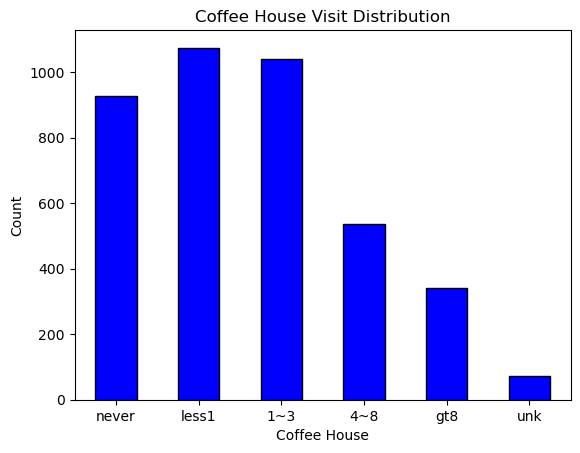

In [61]:
coffee_counts = df_coffee['CoffeeHouse'].value_counts().sort_index()

order = ['never', 'less1', '1~3', '4~8', 'gt8', 'unk']
coffee_counts = coffee_counts.reindex(order, fill_value=0)

coffee_counts.plot(kind='bar', color='blue', edgecolor='black')

plt.title('Coffee House Visit Distribution')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

By accepted count:


Y,0,1
CoffeeHouse,,
1~3,367,675
less1,557,518
4~8,169,369
gt8,117,225
never,752,175
unk,39,33



By total coupon count:


Y,0,1
CoffeeHouse,,
less1,557,518
1~3,367,675
never,752,175
4~8,169,369
gt8,117,225
unk,39,33


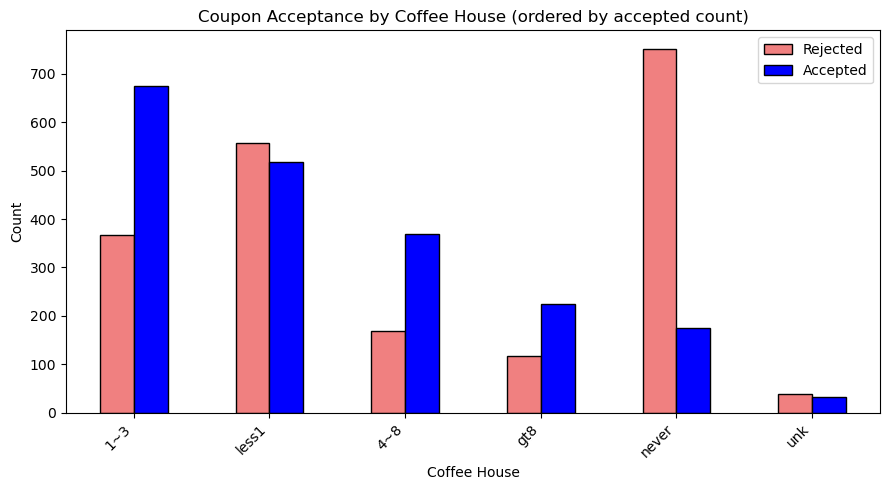

In [62]:
coupon_ct = pd.crosstab(df_coffee['CoffeeHouse'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Coffee House (ordered by accepted count)')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

In [63]:
print(df_coffee['CoffeeHouse'].value_counts())

CoffeeHouse
less1    1075
1~3      1042
never     927
4~8       538
gt8       342
unk        72
Name: count, dtype: int64


3. Compare the acceptance rate between  who went to a bar 3 or fewer times a month to those who went more.
By looking at the distribution of the Coffee House visits, we can see that the majority of the observations are in the "never" and "less1" categories. 
WE will compare the acceptance rate between those who went to a Coffee House 1 or fewer times a month to those who went more.
As we can see, the drivers that go to the coffee house at least one, are twice as likely as the other group to accept the coupons

In [64]:
condition = df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"])

accepted_gr = df_coffee.loc[condition, "Y"].mean()
other_gr = df_coffee.loc[~condition & (df_coffee["CoffeeHouse"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_gr:.2%}")
print(f"All others: {other_gr:.2%}")

Target group: 66.02%
All others: 34.62%


In [65]:
condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["occupation"] != "Farming Fishing & Forestry")
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 71.32%
All others: 29.48%


In [66]:
4. Compare the acceptance rate between drivers who go to a Coffee House more than once a month and are over the age of 25 to the all others.  Is there a difference?

Object `difference` not found.


By accepted count:


Y,0,1
age,,
21,420,463
26,409,434
31,326,297
50plus,316,229
36,214,188
41,162,163
46,107,113
below21,47,108



By total coupon count:


Y,0,1
age,,
21,420,463
26,409,434
31,326,297
50plus,316,229
36,214,188
41,162,163
46,107,113
below21,47,108


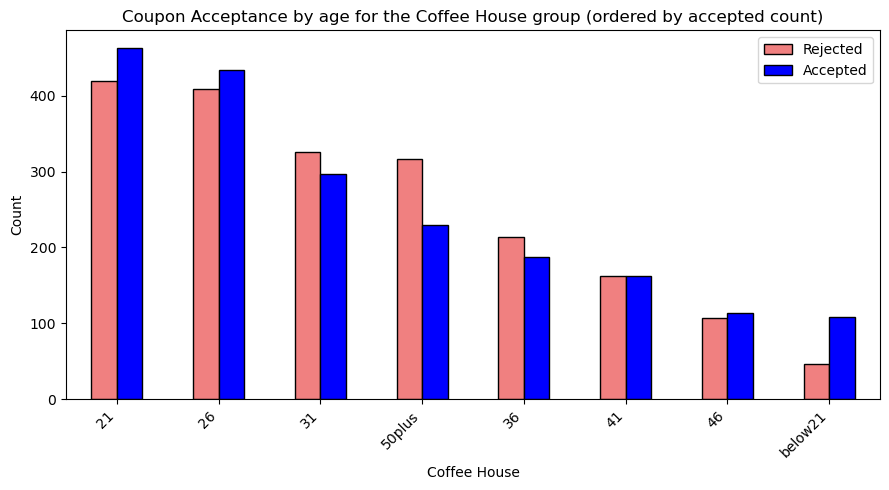

In [67]:
coupon_ct = pd.crosstab(df_coffee['age'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by age for the Coffee House group (ordered by accepted count)')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

#The compare below shows that the younger drivers are more likely to accept the coupon. 

In [68]:
coffee = ["1~3", "4~8", "gt8"]

over25 = ["26", "31", "36", "41", "46", "50plus"]

condition = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    df_coffee["age"].isin(over25)
)

compare = (
    df_coffee.loc[df_coffee["CoffeeHouse"] != "unk"]
    .assign(target_group=condition)
    .groupby("target_group")["Y"]
    .agg(
        Total="count",
        Accepted="sum",
        Acceptance_Rate="mean"
    )
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)

print(compare)

              Total  Accepted  Acceptance_Rate
target_group                                  
False          2566      1095            42.67
True           1358       867            63.84


5. Occupation

By accepted count:


Y,0,1
occupation,,
Student,187,312
Unemployed,261,309
Computer & Mathematical,223,226
Sales & Related,216,139
Management,162,136
Education&Training&Library,167,129
Arts Design Entertainment Sports & Media,103,106
Office & Administrative Support,112,85
Business & Financial,76,70



By total coupon count:


Y,0,1
occupation,,
Unemployed,261,309
Student,187,312
Computer & Mathematical,223,226
Sales & Related,216,139
Management,162,136
Education&Training&Library,167,129
Arts Design Entertainment Sports & Media,103,106
Office & Administrative Support,112,85
Retired,98,66


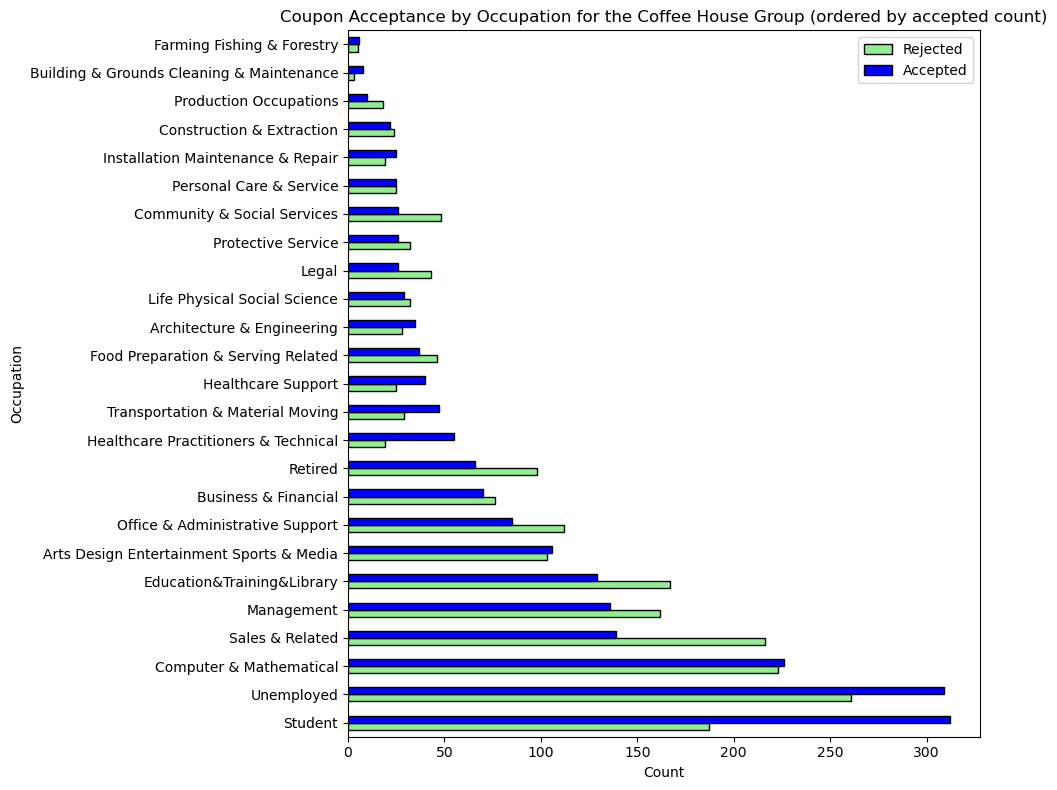

In [69]:
coupon_ct = pd.crosstab(df_coffee['occupation'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='barh',
    figsize=(10, 8),
    color=['lightgreen', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Occupation for the Coffee House Group (ordered by accepted count)')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()


In [70]:
#Create a column that satisfies all conditions for the target group. 
# The target group is defined as drivers who go to bars more than once a month, and had no kid as passanger and not in the farming/fishing/forestry occupation.

coffee = ["1~3", "4~8", "gt8"]

df_coffee["nokid_busy"] = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    (df_coffee["passanger"] != "Kid(s)") &
    (~df_coffee["occupation"].isin(["Retired", "Management"]))
)

compare = (df_coffee.loc[df_coffee["nokid_busy"] == True].groupby("nokid_busy")["Y"].agg(Total="count", Accepted="sum", Acceptance_Rate="mean"))

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare

,Total,Accepted,Acceptance_Rate
nokid_busy,,,
True,1629,1085,66.61


5. #go to cheap restaurants more than 4 times a month and income is less than 50K.

In [71]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

restaurant = ["4~8", "gt8"]

income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

condition = (
    df_coffee["RestaurantLessThan20"].isin(restaurant) &
    df_coffee["income"].isin(income)
)

accepted_group = df_coffee.loc[condition, "Y"].mean()
other_group = df_coffee.loc[~condition & (df_coffee["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 54.30%
All others: 48.89%


Check correlation between Coffee House visits and age

In [72]:
from scipy.stats import spearmanr

coffee_map = {
    "never": 0,
    "less1": 1,
    "1~3": 2,
    "4~8": 3,
    "gt8": 4
}

age_map = {
    "below21": 0,
    "21": 1,
    "26": 2,
    "31": 3,
    "36": 4,
    "41": 5,
    "46": 6,
    "50plus": 7
}

df_corr = df_coffee.copy()

df_corr["Coffee_num"] = df_corr["CoffeeHouse"].map(coffee_map)
df_corr["Age_num"] = df_corr["age"].map(age_map)

# Remove unknowns/missing values
df_corr = df_corr.dropna(subset=["Coffee_num", "Age_num"])

corr, p = spearmanr(df_corr["Coffee_num"], df_corr["Age_num"])

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.4f}")

Spearman correlation: -0.077
p-value: 0.0000


6. Other tests

In [73]:
df_coffee["RestaurantLessThan20"].value_counts()


RestaurantLessThan20
1~3      1679
4~8      1135
less1     649
gt8       431
never      52
unk        50
Name: count, dtype: int64

In [74]:
df_coffee["CoffeeHouse"].value_counts()

CoffeeHouse
less1    1075
1~3      1042
never     927
4~8       538
gt8       342
unk        72
Name: count, dtype: int64

In [75]:
mapping = {
    "never": 0,
    "less1": 1,
    "1~3": 2,
    "4~8": 3,
    "gt8": 4
}

df_corr = df.copy()

df_corr["Coffee_num"] = df_corr["CoffeeHouse"].map(mapping)
df_corr["Restaurant_num"] = df_corr["RestaurantLessThan20"].map(mapping)

# Remove unknowns
df_corr = df_corr.dropna(subset=["Coffee_num", "Restaurant_num"])

In [76]:
corr, p = spearmanr(
    df_corr["Coffee_num"],
    df_corr["Restaurant_num"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.4f}")

Spearman correlation: 0.285
p-value: 0.0000


6. Compare the acceptance rates between those drivers who:

- go to Coffee House more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to Coffee House more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K, in the Coffee House group

In [77]:
#go to Coffee House more than once a month, had passengers that were not a kid, and were not widowed

coffee = ["1~3", "4~8", "gt8"]

condition = df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"])

df_coffee["nokid_wife"] = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    (df_coffee["passanger"] != "Kid(s)") &
    (df_coffee["maritalStatus"] != "Widowed")
)

compare = (
    df_coffee.loc[df_coffee["CoffeeHouse"] != "unk"]
    .groupby("nokid_wife")["Y"]
    .agg(Total="count", Accepted="sum", Acceptance_Rate="mean")
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare

,Total,Accepted,Acceptance_Rate
nokid_wife,,,
False,2111,764,36.19
True,1813,1198,66.08


In [78]:
df_coffee["under30"] = df_coffee["age"].isin(["below21", "21", "26"])

condition = (
    df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"]) &
    df_coffee["under30"]
)

accepted_group = df_coffee.loc[condition, "Y"].mean()
other_group = df_coffee.loc[~condition & (df_coffee["CoffeeHouse"] != "unk"), "Y"].mean()

print(f"Drivers who go to Coffee Houses >1/month and are under 30:: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

#print("Drivers who go to Coffee Houses >1/month and are under 30:", round(accepted_group, 3))

#print("All others:", round(other_group, 3))

Drivers who go to Coffee Houses >1/month and are under 30:: 68.93%
All others: 43.65%


In [79]:
# Income < $50K
income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

df_coffee["Income_lt50k"] = df_coffee["income"].isin(income).astype(int)

pd.crosstab(
    df_coffee["CoffeeHouse"],
    df_coffee["Income_lt50k"],
    margins=True
)

(
    pd.crosstab(
        df_coffee["CoffeeHouse"],
        df_coffee["Income_lt50k"],
        normalize="index"
    ) * 100
).round(2)

Income_lt50k,0,1
CoffeeHouse,,
1~3,47.70,52.30
4~8,45.72,54.28
gt8,45.03,54.97
less1,43.53,56.47
never,50.81,49.19
unk,38.89,61.11


By accepted count:


Y,0,1
income,,
$12500 - $24999,273,321
$37500 - $49999,270,320
$25000 - $37499,337,303
$50000 - $62499,272,276
$100000 or More,270,264
Less than $12500,138,170
$87500 - $99999,120,151
$62500 - $74999,155,120
$75000 - $87499,166,70



By total coupon count:


Y,0,1
income,,
$25000 - $37499,337,303
$12500 - $24999,273,321
$37500 - $49999,270,320
$50000 - $62499,272,276
$100000 or More,270,264
Less than $12500,138,170
$62500 - $74999,155,120
$87500 - $99999,120,151
$75000 - $87499,166,70


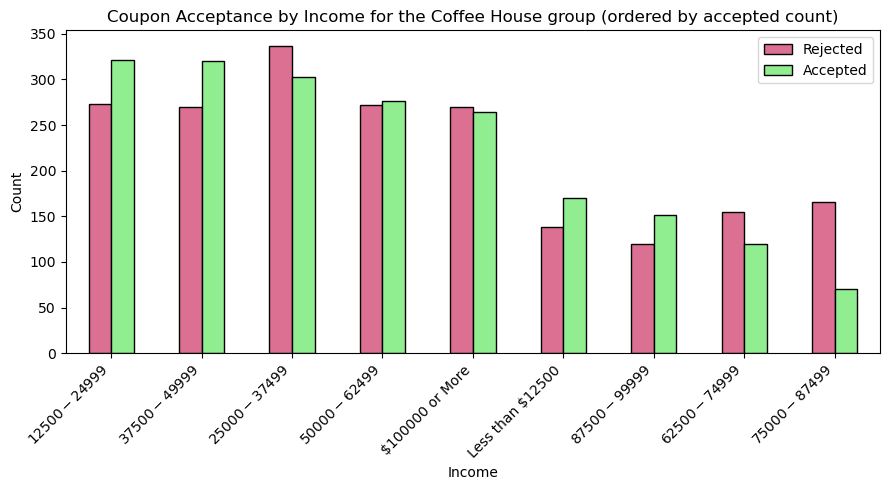

In [80]:
coupon_ct = pd.crosstab(df_coffee['income'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['palevioletred','lightgreen'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Income for the Coffee House group (ordered by accepted count)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

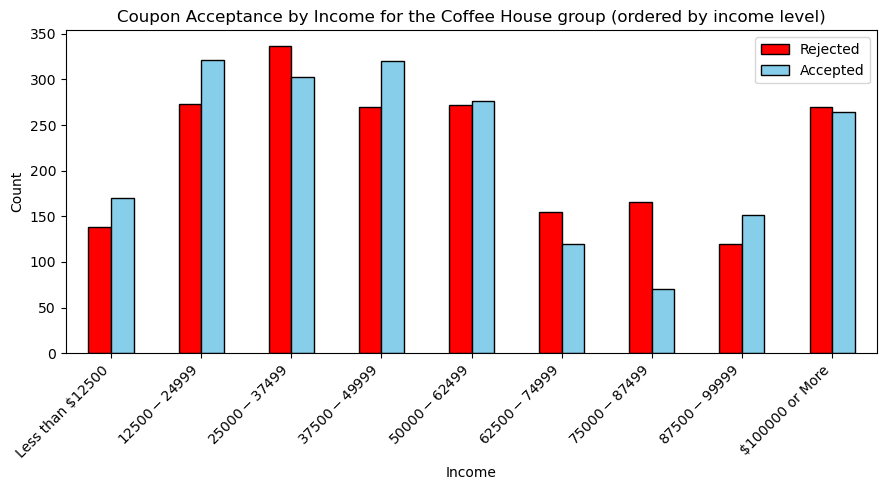

In [81]:
coupon_ct = pd.crosstab(df_coffee['income'], df_coffee['Y'])

coupon_ct[coupon_ct.columns].plot(
    kind='bar',
    figsize=(9,5),
    color=['red','skyblue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Income for the Coffee House group (ordered by income level)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

In [82]:
df["income"].value_counts()

income
$25000 - $37499     2013
$12500 - $24999     1831
$37500 - $49999     1805
$100000 or More     1736
$50000 - $62499     1659
Less than $12500    1042
$87500 - $99999      895
$75000 - $87499      857
$62500 - $74999      846
Name: count, dtype: int64